<a href="https://colab.research.google.com/github/CaptJack05/ML/blob/main/__01__pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Work Flow

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np



torch.__version__

'2.10.0+cu128'

## Data (preparation and loading)

####Data can be almost anything... in machine learning.

* Excel speadsheet
* Images of any kind
* Videos (YouTube has lots of data...)
* Audio like songs or podcasts
* DNA
* Text
####Machine learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

In [ ]:
# create *know* parameters

weight = 0.7
bias = 0.3

#create
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(Y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Let's create a training and test set with our data.

In [ ]:
train_split = int(0.8* len(X))
X_train,Y_train = X[:train_split:], Y[:train_split]

X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

In [ ]:
# Visulizing The Data
def plot_predictions(train_data=X_train,
                      train_labels=Y_train,
                      test_data=X_test,
                      test_labels=Y_test,
                      predictions=None):
  plt.scatter(train_data, train_labels, c="b", s=4, label="training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="testing data")
  if predictions is not None:
    plt.scatter(test_data, predictions , c="r", s=4, label="predictions")
  plt.legend(prop={"size": 14})

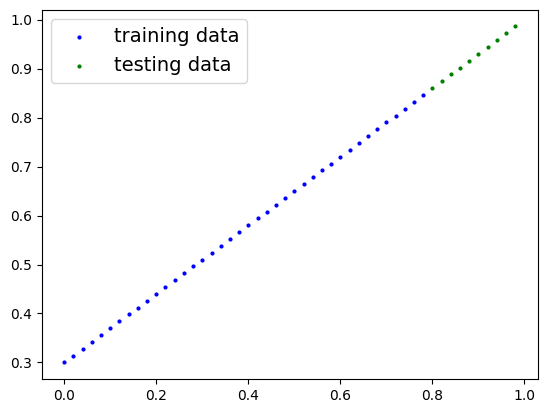

In [ ]:
plot_predictions()

### 2. Build model

Our first PyTorch model!

This is very exciting... let's do it!

Because we're going to be building classes throughout the course, I'd recommend getting familiar with OOP in Python, to do so you can use the following resource from Real Python: https://realpython.com/python3-object-oriented-programming/

What our model does:

* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)
How does it do so?

Through two main algorithms:

1. Gradient descent - https://youtu.be/IHZwWFHWa-w
2. Backpropagation - https://youtu.be/Ilg3gGewQ5U

In [ ]:
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype= torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype= torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [ ]:
LinearRegressionModel()

LinearRegressionModel()

### PyTorch model building essentials
* torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation


See more of these essential modules via the PyTorch cheatsheet - https://pytorch.org/tutorials/beginner/ptcheat.html


Checking the contents of our PyTorch model
Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using .parameters().

In [ ]:
torch.random.manual_seed(42)
#parameters of model

model_0 = LinearRegressionModel()

#checking the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#List parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using 'torch.infrence_mode()'

To check our model's predictive power

In [ ]:
#make pridiction with model

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

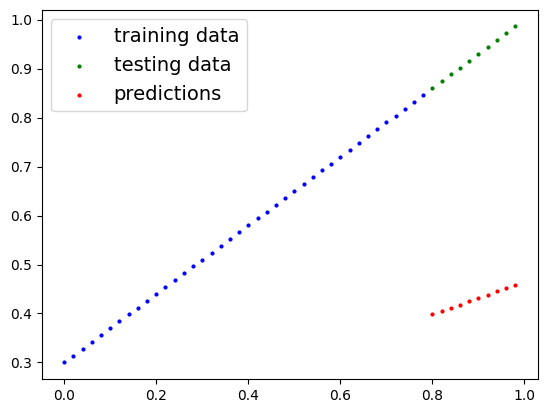

In [ ]:
plot_predictions(predictions= y_preds)

In [ ]:
## Train Model

### Train model

The whole idea of training is for a model to move from some unknown parameters (these may be random) to some known parameters.

Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.
Things we need to train:

* **Loss function:**  A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function - https://pytorch.org/docs/stable/optim.html#module-torch.optim

Inside the optimizer you'll often have to set two parameters:
params - the model parameters you'd like to optimize, for example params=model_0.parameters()
lr (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small lr results in small changes, a large lr results in large changes)

And specifically for PyTorch, we need:

* A training loop
 *A testing loop

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#check out for model's parameters's (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
#Setting up loss function
loss_fn = nn.L1Loss()

#Setting up the optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)  # lr  = learning rate = possibly the most important hyperparameter you can set
#

Q: Which loss function and optimizer should I use?

A: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem (like ours), a loss function of nn.L1Loss() and an optimizer like torch.optim.SGD() will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of nn.BCELoss() (binary cross entropy loss).

## Building a training loop (and a testing loop) in PyTorch
A couple of things we need in a training loop:
0. Loop through the data and do...

1. Forward pass (this involves data moving through our model's forward() functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (backpropagation - https://www.youtube.com/watch?v=tIeHLnjs5U8)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (gradient descent - https://youtu.be/IHZwWFHWa-w)

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
list(model_0.eval().parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
torch.manual_seed(42)
# An epoch is one loop through the data... (this is a hyperparameter because we've set it)
epochs = 200

#Track different values
epochs_count = []
train_loss_values = []
test_loss_values = []

#Loop through data

### Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set model to training mode
  model_0.train() #train mode in PyTorch sets all parameters that require gradient to gradients

  #1 Forward pass
  y_preds = model_0(X_train)

  #2 Calculate the loss
  loss = loss_fn(y_preds, Y_train)


  #3 Optimizer zero grad
  optimizer.zero_grad()

  #4. Perform backpropagation on the loss with respect to the parameters of the modal
  loss.backward()

  #5. Step the optimizer (perform gradient descent)
  optimizer.step()  # by default how the optimizer changes will accumulate through the loop so... we have zerom them above in step 3


### Testing
  model_0.eval()  #turns off different settings in the model not needed for evaluation/testing(droupout /batchnorm layers)
  with torch.inference_mode():  # turn off gradient tracking and couple of more things

    #1. Do the forward pass
    test_preds = model_0(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_preds, Y_test)

 # with torch.no_grad():
 #   test_loss = loss_fn(test_preds, Y_test)




  # print out model state_dict()
  if epoch % 10 == 0:
    epochs_count.append(epoch)
    train_loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} || Loss: {loss} || Test loss: {test_loss}")
    print(model_0.state_dict())


Epoch: 0 || Loss: 0.31288138031959534 || Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 || Loss: 0.1976713240146637 || Test loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 || Loss: 0.08908725529909134 || Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 || Loss: 0.053148526698350906 || Test loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 || Loss: 0.04543796554207802 || Test loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 || Loss: 0.04167863354086876 || Test loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 || Loss: 0.03818932920694351 || Test loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 7

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.6990], requires_grad=True),
 Parameter containing:
 tensor([0.3093], requires_grad=True)]

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

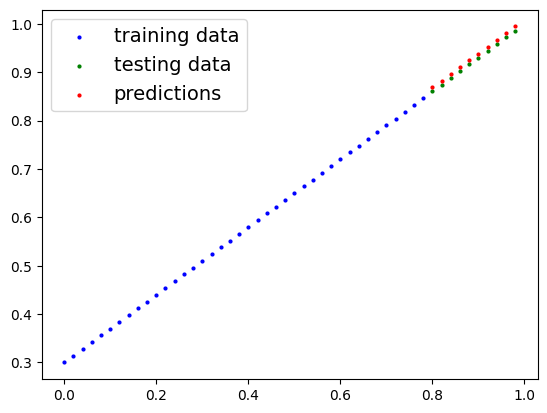

In [ ]:
plot_predictions(predictions= y_preds_new)

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

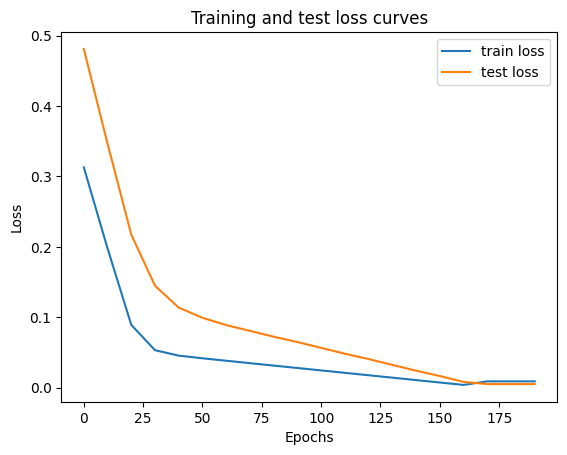

In [ ]:
plt.plot(epochs_count, np.array(torch.tensor(train_loss_values).numpy()), label="train loss")
plt.plot(epochs_count, test_loss_values, label="test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.plot

### Saving a model in PyTorch

Three main method y:

1. 'torch.save()' - allows you to save PyTorch object in Python's pickle format.

2. torch.load() - allows you load a saved PyTorch objects

3. torch.nn.Module.load_state_dict() - this allows to load a model's saved state dictionary

In [ ]:
#Saving our Pytorch model
from pathlib import Path

#1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_workFlow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models/01_workFlow_model_0.pth


### Saving a model in PyTorch

Three main method y:

1. 'torch.save()' - allows you to save PyTorch object in Python's pickle format.

2. torch.load() - allows you load a saved PyTorch objects

3. torch.nn.Module.load_state_dict() - this allows to load a model's saved state dictionary

In [ ]:
#Saving our Pytorch model
from pathlib import Path

#1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_workFlow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

PosixPath('models/01_workFlow_model_0.pth')

In [ ]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 t(this wil update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
#Make some predictions with our loadeded model

loaded_model_0.eval()
with torch.inference_mode():
  loaded_mode_prediction = loaded_model_0(X_test)

loaded_mode_prediction

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

## Revision

In [ ]:
# Importing

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Setting device agnostic

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device: {device}")

using device: cuda


In [ ]:
# Creating Dataset

weight = 0.7
bias = 0.3

start = 0
stop = 1
step = 0.02

x = torch.arange(start, stop, step)
y = weight * x + bias

print(x)
print(y)

tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
        0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
        0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
        0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
        0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
        0.9000, 0.9200, 0.9400, 0.9600, 0.9800])
tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560, 0.3700, 0.3840, 0.3980, 0.4120,
        0.4260, 0.4400, 0.4540, 0.4680, 0.4820, 0.4960, 0.5100, 0.5240, 0.5380,
        0.5520, 0.5660, 0.5800, 0.5940, 0.6080, 0.6220, 0.6360, 0.6500, 0.6640,
        0.6780, 0.6920, 0.7060, 0.7200, 0.7340, 0.7480, 0.7620, 0.7760, 0.7900,
        0.8040, 0.8180, 0.8320, 0.8460, 0.8600, 0.8740, 0.8880, 0.9020, 0.9160,
        0.9300, 0.9440, 0.9580, 0.9720, 0.9860])


In [ ]:
# Splitting the data for train ,test evaluate and

train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

In [ ]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

(torch.Size([40]), torch.Size([10]), torch.Size([40]), torch.Size([10]))

In [ ]:
# visulization

def ploting_function(
    train_data=x_train,
    train_labels=y_train,
    test_data=x_test,
    test_labels=y_test,
    prediction= None):

  plt.scatter(train_data, train_labels, c="b", s=4, label="training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="testing data")

  if prediction is not None:
    plt.scatter(test_data, prediction, c="r", s=4, label="prediction")

  plt.legend(prop={"size": 14})


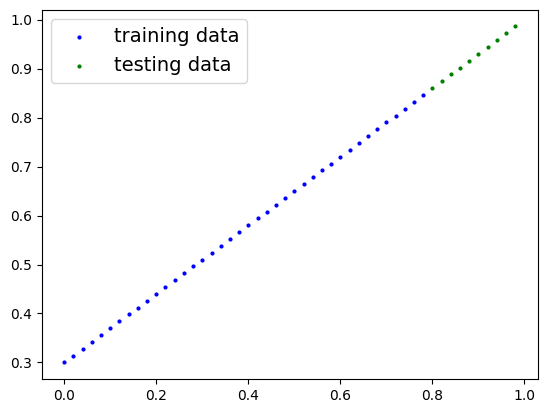

In [ ]:
ploting_function()

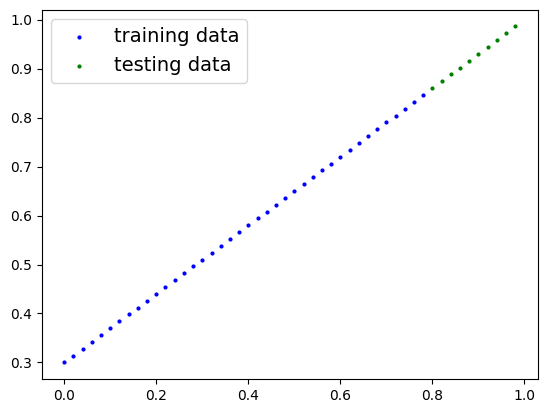

In [ ]:
plot_predictions(x_train, y_train, x_test, y_test)

In [ ]:
# Building the Model

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype= torch.float32))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias


In [ ]:
# instiantiating the model

revised_model = LinearRegressionModelV2()

list(revised_model.parameters()), revised_model.state_dict()


([Parameter containing:
  tensor([0.2345], requires_grad=True),
  Parameter containing:
  tensor([0.2303], requires_grad=True)],
 OrderedDict([('weights', tensor([0.2345])), ('bias', tensor([0.2303]))]))

In [ ]:
#making the prediction

with torch.inference_mode():
  revised_prediction = revised_model(x_test)

revised_prediction

tensor([0.4179, 0.4226, 0.4273, 0.4320, 0.4367, 0.4413, 0.4460, 0.4507, 0.4554,
        0.4601])

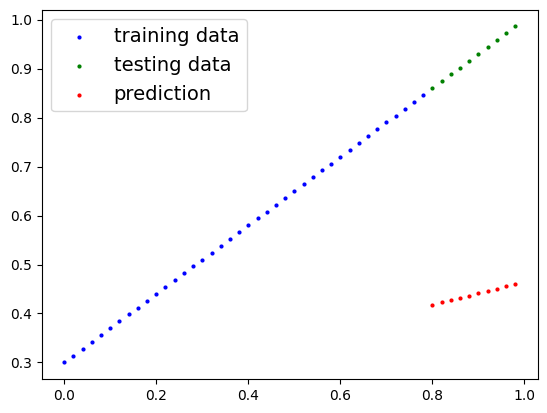

In [ ]:
ploting_function(x_train, y_train, x_test, y_test, revised_prediction)

In [ ]:
# Setting up the loss function

loss_fn = nn.L1Loss()

#setting optimizer

optimizer = torch.optim.SGD(params=revised_model.parameters(),
                            lr=0.01)

In [ ]:
with torch.inference_mode():
  revised_prediction = revised_model(x_test)

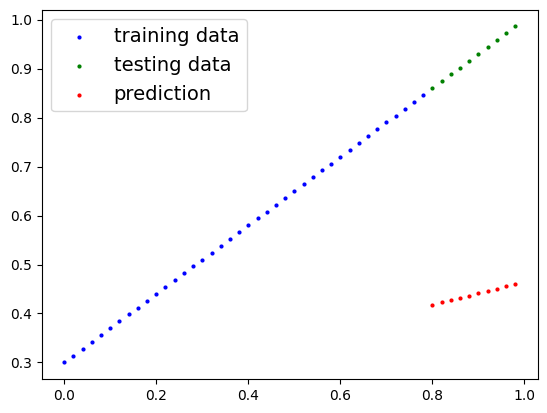

In [ ]:
ploting_function(x_train, y_train, x_test, y_test, revised_prediction)

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

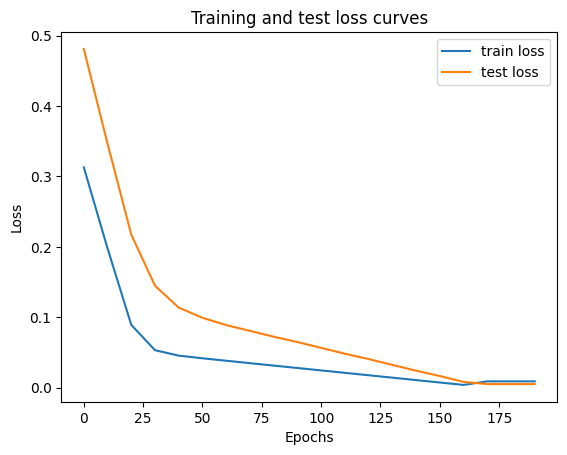

In [ ]:
plt.plot(epochs_count, np.array(torch.tensor(train_loss_values).numpy()), label="train loss")
plt.plot(epochs_count, test_loss_values, label="test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.plot

In [ ]:
# Creating linear model by sublcassing nn.model
class LinearRegressionModelV3(nn.Module):
  def __init__(self):
    super().__init__()
    # use nn.Linear for creating the model parameter
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [ ]:
#new model
model_new = LinearRegressionModelV3()


In [ ]:
model_new.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.8815]])),
             ('linear_layer.bias', tensor([-0.7336]))])

In [ ]:
list(model_new.parameters())

[Parameter containing:
 tensor([[0.8815]], requires_grad=True),
 Parameter containing:
 tensor([-0.7336], requires_grad=True)]

In [ ]:
# Splitting the data for train ,test evaluate and

train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

In [ ]:


x_train.shape , y_train.shape , x_test.shape , y_test.shape

(torch.Size([40]), torch.Size([40]), torch.Size([10]), torch.Size([10]))

In [ ]:
next(model_new.parameters()).device

device(type='cpu')

In [ ]:
model_new.to(device)
next(model_new.parameters()).device

device(type='cuda', index=0)

In [ ]:
#loss function
loss_function = nn.L1Loss()

# optimizer
optimizer = torch.optim.SGD(params=model_new.parameters(),
                            lr=0.01)

In [ ]:
# Traing the model

epochs = 1000

#putting data on the target device
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)

# Reshape x_train, x_test to (N, 1) for nn.Linear
x_train = x_train.unsqueeze(dim=1)
x_test = x_test.unsqueeze(dim=1)
# Reshape y_train, y_test to (N, 1) to match output of nn.Linear for loss calculation
y_train = y_train.unsqueeze(dim=1)
y_test = y_test.unsqueeze(dim=1)

#tracking

epochs_count = []
training_loss = []
testing_loss = []



for epoch in range(epochs):

  #setting for traingin
  model_new.train()

  #Forward pass
  y_prediction = model_new(x_train)

  #loss
  loss = loss_function(y_prediction, y_train)

  #optimizer
  optimizer.zero_grad()

  #backpropagation
  loss.backward()
  # gradient descent
  optimizer.step()

  #testing
  model_new.eval()

  with torch.no_grad():
    y_test_predictions = model_new(x_test)

    test_loss = loss_function(y_test_predictions, y_test)

  if epoch % 10 == 0:
    epochs_count.append(epoch)
    training_loss.append(loss)
    testing_loss.append(test_loss)
    print(f"Epoch: {epoch} || Loss: {loss} || Test loss: {test_loss}")

Epoch: 0 || Loss: 0.9628263711929321 || Test loss: 0.858583927154541
Epoch: 10 || Loss: 0.8476166129112244 || Test loss: 0.7238741517066956
Epoch: 20 || Loss: 0.732406735420227 || Test loss: 0.5891643762588501
Epoch: 30 || Loss: 0.617196798324585 || Test loss: 0.4544544219970703
Epoch: 40 || Loss: 0.5019866824150085 || Test loss: 0.3197440803050995
Epoch: 50 || Loss: 0.38677656650543213 || Test loss: 0.1850336641073227
Epoch: 60 || Loss: 0.2715663015842438 || Test loss: 0.05032316595315933
Epoch: 70 || Loss: 0.1586626023054123 || Test loss: 0.08102553337812424
Epoch: 80 || Loss: 0.11361625045537949 || Test loss: 0.15223388373851776
Epoch: 90 || Loss: 0.10002555698156357 || Test loss: 0.18380697071552277
Epoch: 100 || Loss: 0.0938224196434021 || Test loss: 0.1965152472257614
Epoch: 110 || Loss: 0.08965343236923218 || Test loss: 0.1986268311738968
Epoch: 120 || Loss: 0.08612531423568726 || Test loss: 0.19447575509548187
Epoch: 130 || Loss: 0.08259718865156174 || Test loss: 0.190324664115

In [ ]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: torch.Size([40, 1])
y_train shape: torch.Size([40, 1])
x_test shape: torch.Size([10, 1])
y_test shape: torch.Size([10, 1])


In [ ]:
model_new.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7028]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.2919], device='cuda:0'))])

In [ ]:
model_new.eval()

with torch.inference_mode():
  y_predictions = model_new(x_test)

y_predictions

tensor([[0.8541],
        [0.8681],
        [0.8822],
        [0.8963],
        [0.9103],
        [0.9244],
        [0.9384],
        [0.9525],
        [0.9665],
        [0.9806]], device='cuda:0')

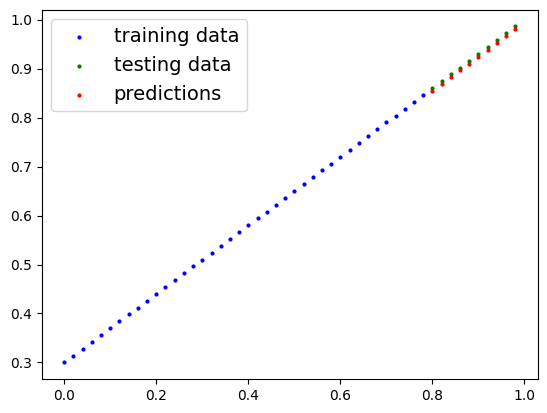

In [ ]:
plot_predictions(predictions=y_predictions.cpu())

In [ ]:
#

In [ ]:
from pathlib import Path

# 1. crate model direactory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. create model save path
MODEL_NAME = "_01_pyTorch_New_Model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_new.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/_01_pyTorch_New_Model
